In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")
RANDOM_STATE = 42
DATA_PATH = Path("/Users/choseoyeon/Desktop/umich/670/project/clean_posts_ready.csv")


In [2]:
df = pd.read_csv(DATA_PATH)

initial_rows = len(df)
missing_target = df["engagement_rate"].isna().sum()

print(f"Original sample count: {initial_rows:,}, Number of features: {df.shape[1]}")
if missing_target:
    print(
        f"{missing_target:,} missing engagement_rate rows removed -> {initial_rows - missing_target:,} samples used"
    )

df = df.dropna(subset=["engagement_rate"]).copy()

print(f"Samples for modeling: {len(df):,}, Number of features: {df.shape[1]}")
display(df.head(3))

engagement_summary = df["engagement_rate"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
missing_snapshot = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .to_frame(name="missing_ratio")
)

print("\nengagement_rate distribution summary:")
display(engagement_summary)

print("\nTop 10 features by missing ratio:")
display(missing_snapshot)


Original sample count: 2,000, Number of features: 28
31 missing engagement_rate rows removed -> 1,969 samples used
Samples for modeling: 1,969, Number of features: 28


,post_id,timestamp,is_video,like_count,comment_count,owner_username,owner_is_verified,caption_text_en,comments_en,caption_sentiment,...,has_hashtag,caption_length,num_emojis,contains_mention,has_url,engagement_score,like_to_comment_ratio,is_ad_text,followers,engagement_rate
0,1830138903170861888,2018-07-23 23:46:20,False,321,16.0,lelien_tomo,False,"My grandmother's sewing machine, which I loved...","[""The sewing machine is as beautiful as new ❤️...",positive,...,1,705,0,1,1,337.0,18.882353,False,8663.0,0.038901
1,1489332816747241995,2017-04-09 18:25:28,False,33,0.0,veverkakokos,False,Today the weather was like this again 😍 what c...,[],positive,...,1,127,1,0,0,33.0,33.000000,False,3993.0,0.008264
2,1969215886536407515,2019-01-31 21:07:28,False,69,2.0,alicekings,False,Quack,['!! Fin'],neutral,...,0,5,0,0,0,71.0,23.000000,False,3537.0,0.020074



engagement_rate distribution summary:


count      1969.000000
mean        338.808535
std        3766.060911
min           0.000130
25%           0.013047
50%           0.035121
75%           1.761905
90%         345.400000
95%        1019.400000
max      152699.000000
Name: engagement_rate, dtype: float64


Top 10 features by missing ratio:


,missing_ratio
caption_text_clean,0.019299
caption_text_en,0.017268
comments_clean,0.000000
followers,0.000000
is_ad_text,0.000000
like_to_comment_ratio,0.000000
engagement_score,0.000000
has_url,0.000000
contains_mention,0.000000
num_emojis,0.000000


In [3]:
EXCLUDED_FEATURES = [
    "engagement_rate",
    "engagement_score",
    "like_count",
    "comment_count",
    "like_to_comment_ratio"
]

numeric_df = df.select_dtypes(include=[np.number]).copy()
X = numeric_df.drop(columns=[col for col in EXCLUDED_FEATURES if col in numeric_df.columns])
y = df["engagement_rate"].astype(float)

print(f"Number of available numeric features: {X.shape[1]}")
feature_preview = pd.Series(X.columns).sort_values().head(15)
print("Feature examples:")
display(feature_preview)

ranked = y.rank(method="first")
stratify_labels = pd.qcut(ranked, q=5, labels=False)

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_labels
)

median_threshold = y_train_reg.median()
y_train_clf = (y_train_reg >= median_threshold).astype(int)
y_test_clf = (y_test_reg >= median_threshold).astype(int)

class_balance = (
    pd.DataFrame({
        "count": y_train_clf.value_counts().sort_index(),
        "ratio": y_train_clf.value_counts(normalize=True).sort_index()
    })
    .rename(index={0: "Low", 1: "High"})
)

print(f"Training set median threshold: {median_threshold:.4f}")
print("Class distribution for logistic regression:")
display(class_balance)


Number of available numeric features: 12
Feature examples:


7             caption_length
4     comment_negative_ratio
3      comment_neutral_ratio
2     comment_positive_ratio
1     comments_sentiment_avg
9           contains_mention
11                 followers
6                has_hashtag
10                   has_url
8                 num_emojis
5               num_hashtags
0                    post_id
dtype: object

Training set median threshold: 0.0356
Class distribution for logistic regression:


,count,ratio
engagement_rate,,
Low,787,0.499683
High,788,0.500317


Logistic Regression Baseline Performance (Test Set)


,precision,recall,f1-score,support
Low,0.688742,0.507317,0.584270,205.000000
High,0.584362,0.751323,0.657407,189.000000
accuracy,0.624365,0.624365,0.624365,0.624365
macro avg,0.636552,0.629320,0.620839,394.000000
weighted avg,0.638671,0.624365,0.619354,394.000000


ROC-AUC: 0.655


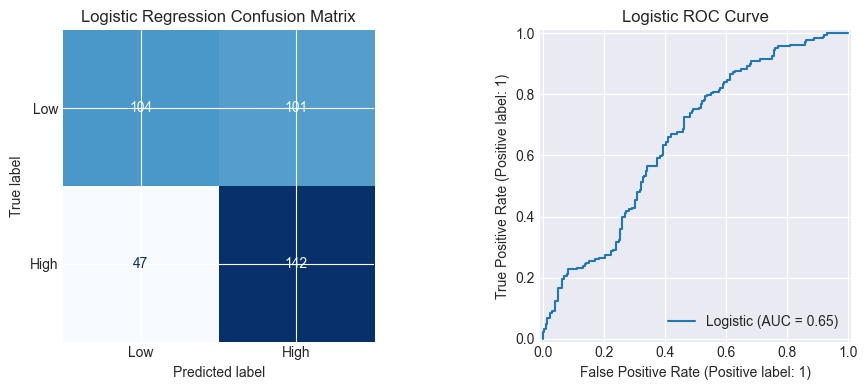

Top 10 features by influence (absolute value)


,coefficient
followers,-3.435940
has_hashtag,-0.219515
comment_negative_ratio,0.061279
contains_mention,-0.051515
comment_neutral_ratio,-0.046439
has_url,-0.035277
comment_positive_ratio,0.035023
num_hashtags,0.030539
comments_sentiment_avg,0.022725
post_id,-0.010255


In [4]:
logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logistic_pipeline.fit(X_train, y_train_clf)

y_pred_clf = logistic_pipeline.predict(X_test)
y_prob_clf = logistic_pipeline.predict_proba(X_test)[:, 1]

report_dict = classification_report(
    y_test_clf,
    y_pred_clf,
    target_names=["Low", "High"],
    output_dict=True
)
report_df = pd.DataFrame(report_dict).T
roc_auc = roc_auc_score(y_test_clf, y_prob_clf)

print("Logistic Regression Baseline Performance (Test Set)")
display(report_df)
print(f"ROC-AUC: {roc_auc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_clf,
    y_pred_clf,
    display_labels=["Low", "High"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Logistic Regression Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test_clf,
    y_prob_clf,
    ax=axes[1],
    name="Logistic"
)
axes[1].set_title("Logistic ROC Curve")
plt.tight_layout()
plt.show()

coef_series = pd.Series(
    logistic_pipeline.named_steps["model"].coef_[0],
    index=X_train.columns
).sort_values(key=lambda s: s.abs(), ascending=False)

print("Top 10 features by influence (absolute value)")
display(coef_series.head(10).to_frame(name="coefficient"))


Decision Tree Classification Performance (Test Set)


,precision,recall,f1-score,support
Low,0.752174,0.843902,0.795402,205.000000
High,0.804878,0.698413,0.747875,189.000000
accuracy,0.774112,0.774112,0.774112,0.774112
macro avg,0.778526,0.771158,0.771639,394.000000
weighted avg,0.777456,0.774112,0.772604,394.000000


ROC-AUC: 0.846


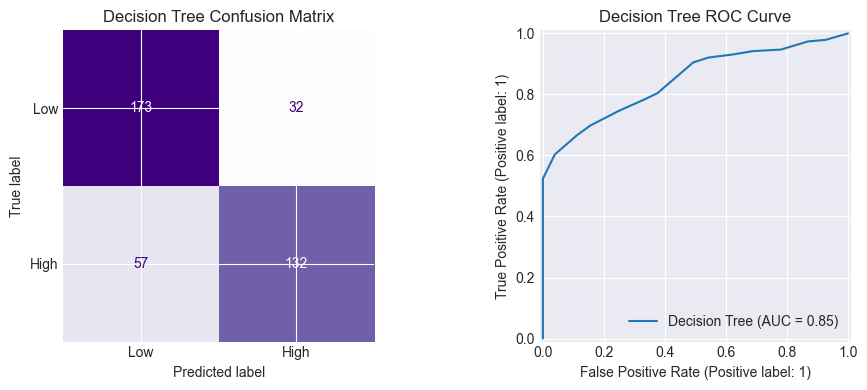

Top 10 Important Features for Decision Tree Classification


,importance
followers,0.890061
comment_neutral_ratio,0.042308
comment_positive_ratio,0.025328
num_hashtags,0.024964
comment_negative_ratio,0.009575
num_emojis,0.007763
post_id,0.000000
comments_sentiment_avg,0.000000
has_hashtag,0.000000
caption_length,0.000000


In [5]:
tree_clf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=60,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

tree_clf_pipeline.fit(X_train, y_train_clf)

y_pred_tree_clf = tree_clf_pipeline.predict(X_test)
y_prob_tree_clf = tree_clf_pipeline.predict_proba(X_test)[:, 1]

tree_clf_report = classification_report(
    y_test_clf,
    y_pred_tree_clf,
    target_names=["Low", "High"],
    output_dict=True
)
tree_clf_report_df = pd.DataFrame(tree_clf_report).T
tree_clf_roc_auc = roc_auc_score(y_test_clf, y_prob_tree_clf)

print("Decision Tree Classification Performance (Test Set)")
display(tree_clf_report_df)
print(f"ROC-AUC: {tree_clf_roc_auc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_clf,
    y_pred_tree_clf,
    display_labels=["Low", "High"],
    cmap="Purples",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Decision Tree Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test_clf,
    y_prob_tree_clf,
    ax=axes[1],
    name="Decision Tree"
)
axes[1].set_title("Decision Tree ROC Curve")
plt.tight_layout()
plt.show()

importance_clf = pd.Series(
    tree_clf_pipeline.named_steps["model"].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 10 Important Features for Decision Tree Classification")
display(importance_clf.head(10).to_frame(name="importance"))


Decision Tree Regression Performance (Test Set)
MAE : 658.78601
RMSE: 7767.23922
R^2 : 0.027


/var/folders/00/hlc640bs3hx3jf_rqtdxfpkc0000gn/T/ipykernel_7608/4006159328.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features, y=top_features.index, palette="viridis", ax=ax)


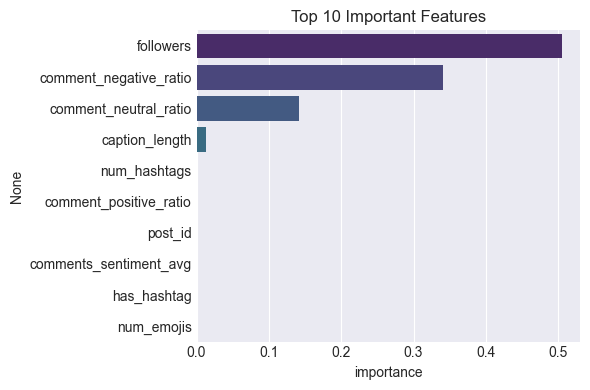

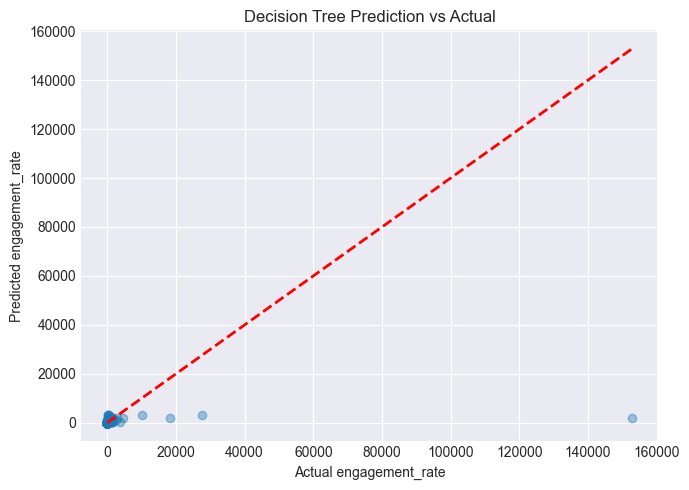

In [13]:
tree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=50,
        random_state=RANDOM_STATE
    ))
])

upper_quartile = y_train_reg.quantile(0.75)
sample_weight_train = np.where(y_train_reg.values >= upper_quartile, 3.0, 1.0)

tree_pipeline.fit(X_train, y_train_reg, model__sample_weight=sample_weight_train)

y_pred_reg = tree_pipeline.predict(X_test)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Decision Tree Regression Performance (Test Set)")
print(f"MAE : {mae:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"R^2 : {r2:.3f}")

importances = pd.Series(
    tree_pipeline.named_steps["model"].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_features = importances.head(10)
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=top_features, y=top_features.index, palette="viridis", ax=ax)
ax.set_title("Top 10 Important Features")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test_reg, y_pred_reg, alpha=0.4)
ax.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], "r--", lw=2)
ax.set_xlabel("Actual engagement_rate")
ax.set_ylabel("Predicted engagement_rate")
ax.set_title("Decision Tree Prediction vs Actual")
plt.tight_layout()
plt.show()


### Notes
- engagement_rate was binarized based on the training set median (above/below) to construct logistic regression and decision tree classification models, both using `class_weight='balanced'` or weighting strategies to mitigate class imbalance.
- Like/comment counts and their derived features (`like_count`, `comment_count`, `engagement_score`, `like_to_comment_ratio`, `engagement_rate`) were all excluded from input features.
- In the logistic/decision tree classification cells, the `classification_report` table, confusion matrix, and ROC curve can be viewed together, allowing visual comparison of the decision tree's improvement over the baseline.
- For decision tree regression, higher weights (3.0) were assigned to samples in the top 25% quartile to emphasize rare high engagement cases.
- All pipelines handle missing values with `SimpleImputer`, and the logistic model includes `StandardScaler` for stable learning. Tree depth, leaf size, sample weights, etc. can be adjusted for additional experiments as needed.
